# Voyage Analytics — Price Prediction

Two regression models:
1. **Flight price** — from route, class, agency, distance, time, and seasonality.
2. **Hotel price** — from hotel, city, stay length, and seasonality.

Both use a `RandomForestRegressor` inside a scikit-learn `Pipeline` (with `ColumnTransformer`
preprocessing), matching what's saved to `models/` for the Streamlit app.

In [10]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep import load_raw, build_flight_price_table, build_hotel_price_table
from train_price_model import train_flight_price_model, train_hotel_price_model

sns.set_style('whitegrid')
users, flights, hotels = load_raw()

## 1. Flight price model

In [11]:
flight_df = build_flight_price_table(flights)
flight_df[['distance', 'time', 'month', 'day_of_week', 'from', 'to', 'flightType', 'agency', 'price']].head()

,distance,time,month,day_of_week,from,to,flightType,agency,price
0,676.53,1.76,9,3,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,1434.38
1,676.53,1.76,9,0,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,1292.29
2,637.56,1.66,10,3,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,1487.52
3,637.56,1.66,10,4,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,1127.36
4,830.86,2.16,10,3,Aracaju (SE),Salvador (BH),firstClass,CloudFy,1684.05


In [12]:
flight_model, flight_r2, flight_mae = train_flight_price_model(flights)

2026/07/10 14:03:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Flight price model] R2=0.9948  MAE=13.94


R² above 0.99 makes sense here: flight class (`economic` / `premium` / `firstClass`) creates near-deterministic price bands in this dataset, and distance explains the rest almost linearly.

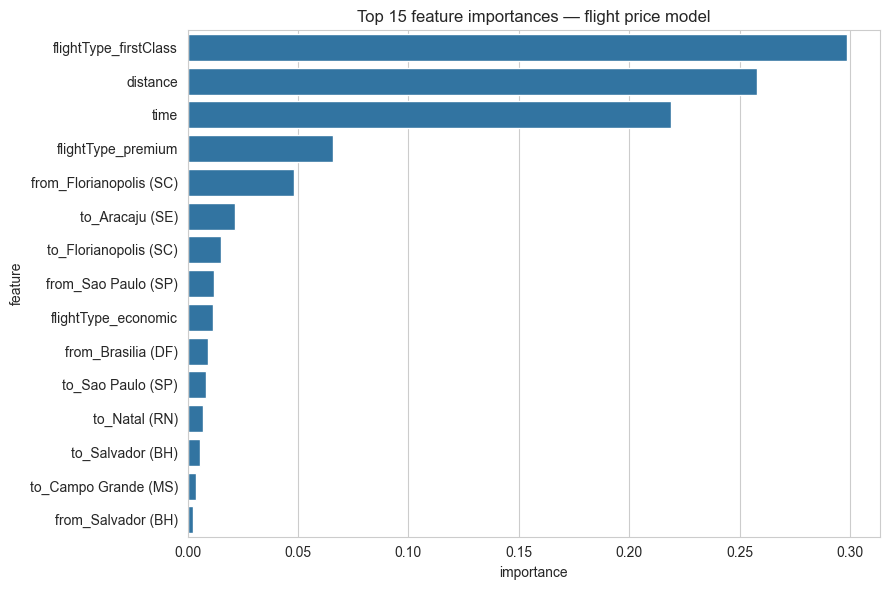

In [13]:
# Feature importance from the underlying RandomForest
import numpy as np
ohe = flight_model.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(['from', 'to', 'flightType', 'agency'])
num_features = ['distance', 'time', 'month', 'day_of_week']
all_features = list(num_features) + list(cat_features)

importances = flight_model.named_steps['regressor'].feature_importances_
imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 feature importances — flight price model')
plt.tight_layout()
plt.show()

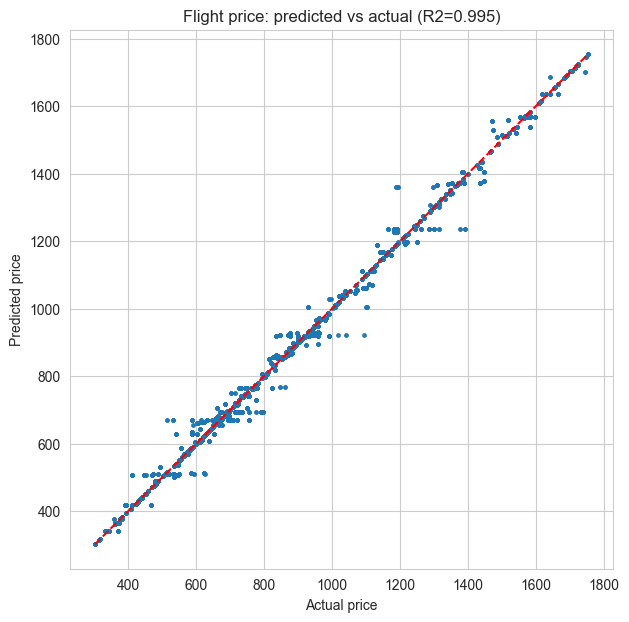

In [14]:
# Predicted vs actual on a held-out sample
from sklearn.model_selection import train_test_split
X = flight_df[['distance', 'time', 'month', 'day_of_week', 'from', 'to', 'flightType', 'agency']]
y = flight_df['price']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = flight_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.1, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title(f'Flight price: predicted vs actual (R2={flight_r2:.3f})')
plt.show()

## 2. Hotel price model

In [15]:
hotel_df = build_hotel_price_table(hotels)
hotel_df[['days', 'month', 'day_of_week', 'name', 'place', 'price']].head()

,days,month,day_of_week,name,place,price
0,4,9,3,Hotel A,Florianopolis (SC),313.02
1,2,10,3,Hotel K,Salvador (BH),263.41
2,3,11,3,Hotel K,Salvador (BH),263.41
3,4,12,3,Hotel K,Salvador (BH),263.41
4,1,12,3,Hotel A,Florianopolis (SC),313.02


In [16]:
hotel_model, hotel_r2, hotel_mae = train_hotel_price_model(hotels)

2026/07/10 14:03:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Hotel price model] R2=1.0000  MAE=0.00


Hotel price is essentially deterministic per (hotel, city) in this dataset — each named hotel has a near-fixed nightly rate — hence R²≈1.0. This is a property of the synthetic dataset, worth calling out rather than treating as a modelling triumph.

In [17]:
print('Sample hotel price consistency check:')
print(hotels.groupby(['name', 'place'])['price'].agg(['mean', 'std']).sort_values('std', ascending=False).head(10))

Sample hotel price consistency check:
                                mean  std
name     place                           
Hotel A  Florianopolis (SC)   313.02  0.0
Hotel AF Sao Paulo (SP)       139.10  0.0
Hotel AU Recife (PE)          312.83  0.0
Hotel BD Natal (RN)           242.88  0.0
Hotel BP Brasilia (DF)        247.62  0.0
Hotel BW Campo Grande (MS)     60.39  0.0
Hotel CB Rio de Janeiro (RJ)  165.99  0.0
Hotel K  Salvador (BH)        263.41  0.0
Hotel Z  Aracaju (SE)         208.04  0.0


## 3. Saved artifacts

Both pipelines are saved to `models/flight_price_model.joblib` and `models/hotel_price_model.joblib`, and loaded directly by `main.py` for live predictions in the Streamlit app.

In [18]:
import os
print(os.listdir('../models'))

['flight_price_model.joblib', 'gender_model.joblib', 'hotel_price_model.joblib', 'recommender_artifacts.joblib', 'segmentation_model.joblib', 'user_segments.csv']
